In [1]:
import pypulseq as pp
import numpy as np
import math

fov = 30e-3  # Define FOV and resolution
Nx = 128
Ny = Nx
alpha = 90  # Flip angle
slice_thickness = 0.8e-3  # Slice thickness
n_slices = 1
TE = 15e-3  # Echo time
TR = 500e-3  # Repetition time

rf_spoiling_inc = 117  # RF spoiling increment
dwell_time = 20.1e-6  # Dwell time need to be a value from the list available here : https://github.com/PreclinicalPulseq/bruker_pulseq_utils/issues/2
# for example 20e-6 or 20.1-6

spoiler_duration = 3e-3  # Spoiler duration
crush_duration = 0.5e-3  # Crusher duration

# Set system limits
system = pp.Opts(
    max_grad=300,
    grad_unit='mT/m',
    max_slew=2000,
    slew_unit='T/m/s',
    rf_ringdown_time=20e-6,
    rf_raster_time=1e-7, # real value for advance neo : 12.5ns
    rf_dead_time=100e-6,
    adc_dead_time=10e-6,
    grad_raster_time=10e-6 # real value for advance neo : 1us
)

seq = pp.Sequence(system)  # Create a new sequence object


## Create events

In [2]:
# ro_duration needs to finish on a raster cell
ADC_del = Nx * dwell_time
ro_duration = round(math.ceil(ADC_del / system.grad_raster_time) * system.grad_raster_time,12)

delay_adc = round((ro_duration - ADC_del)/2,12)
print(ADC_del)
print(ro_duration)
print(delay_adc)

0.0025728
0.00258
3.6e-06


In [3]:
rf, gz, _ = pp.make_sinc_pulse(
  flip_angle=alpha * np.pi / 180,
  duration=2e-3,
  slice_thickness=slice_thickness,
  apodization=0.5,
  time_bw_product=4,
  system=system,
  return_gz=True,
  delay=system.rf_dead_time,
)

rf_180, gz_180, _ = pp.make_gauss_pulse(
  flip_angle=np.pi,
  duration=2e-3,
  slice_thickness=slice_thickness*10,
  apodization=0.5,
  time_bw_product=4,
  system=system,
  return_gz=True,
  delay=system.rf_dead_time,
)


# Define other gradients and ADC events
delta_k = 1 / fov
gx = pp.make_trapezoid(channel='x', flat_area=Nx * delta_k, flat_time=ro_duration, system=system)
adc = pp.make_adc(num_samples=Nx, dwell=dwell_time, delay=gx.rise_time+delay_adc, system=system)
gx_pre = pp.make_trapezoid(channel='x', area=-gx.area / 2, duration=1e-3, system=system)
gz_reph = pp.make_trapezoid(channel='z', area=-gz.area / 2, duration=1e-3, system=system)

gy_pre = pp.make_trapezoid(
        channel='y',
        area= Ny / 2 * delta_k,
        duration=pp.calc_duration(gx_pre),
        system=system,
    )

scale_area = np.linspace(-1,1,Ny)

In [4]:
# Gradient spoiling
gx_spoil = pp.make_trapezoid(channel='x', area=2 * Nx * delta_k,duration=spoiler_duration, system=system)
gz_spoil = pp.make_trapezoid(channel='z', area=4 / slice_thickness,duration=spoiler_duration, system=system)

crush = pp.make_trapezoid(channel='z', area=4 /(slice_thickness * 10) , duration=crush_duration, system=system)


In [5]:
gz_180

namespace(type='trap',
          channel='z',
          amplitude=250000.0,
          rise_time=1e-05,
          flat_time=0.002,
          fall_time=1e-05,
          area=502.4999999999999,
          flat_area=500.0,
          delay=9e-05,
          first=0,
          last=0)

In [6]:
# Calculate timing
delay_TE1 = (
    math.ceil(
        (TE/2 - pp.calc_duration(crush) - pp.calc_duration(gz_180)/2 - pp.calc_duration(gz) / 2 )
        / seq.grad_raster_time
    )
    * seq.grad_raster_time
)

delay_TE2 = (
    math.ceil(
        (TE/2 - pp.calc_duration(crush) - pp.calc_duration(gx_pre) - pp.calc_duration(gz_180)/2 - pp.calc_duration(gx) / 2)
        / seq.grad_raster_time
    )
    * seq.grad_raster_time
)

delay_TR = (
    math.ceil(
        (TR - pp.calc_duration(gz) - pp.calc_duration(gx_pre) - pp.calc_duration(gx) - delay_TE1 - delay_TE2 - 2 * pp.calc_duration(crush) - pp.calc_duration(gz_180) -
        np.maximum(pp.calc_duration(gx_spoil), pp.calc_duration(gz_spoil)))
        / seq.grad_raster_time
    )
    * seq.grad_raster_time
)


In [7]:
delay_TR

0.47962000000000005

In [8]:
assert np.all(delay_TE1 >= 0)
assert np.all(delay_TE2 >= 0)
assert np.all(delay_TR >= pp.calc_duration(gx_spoil, gz_spoil))


# Sample block

In [9]:
seq = pp.Sequence(system)  # Create a new sequence object

seq.add_block(rf, gz)
seq.add_block(pp.make_delay(delay_TE1))
seq.add_block(crush)
seq.add_block(rf_180, gz_180)
seq.add_block(crush)
seq.add_block(pp.make_delay(delay_TE2))
seq.add_block(gx_pre, pp.scale_grad(grad=gy_pre,scale=scale_area[1]), gz_reph)
seq.add_block(gx, adc)
seq.add_block(gx_spoil, pp.scale_grad(grad=gy_pre,scale=-scale_area[1]), gz_spoil)
seq.add_block(pp.make_delay(delay_TR))

seq.add_block(rf, gz)

In [10]:
ok, error_report = seq.check_timing()

if ok:
    print('Timing check passed successfully')
else:
    print('Timing check failed. Error listing follows:')
    [print(e) for e in error_report]

Timing check passed successfully


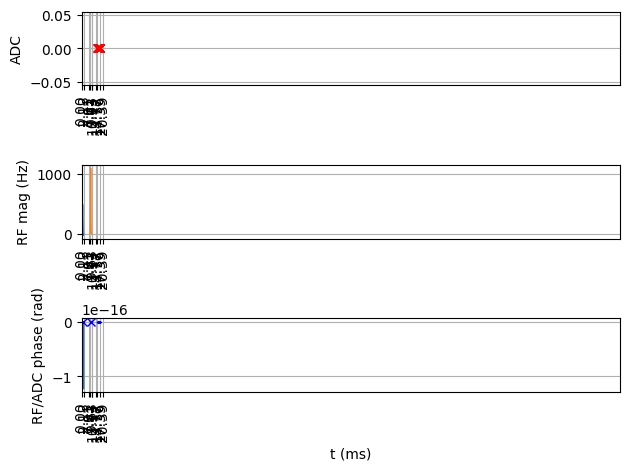

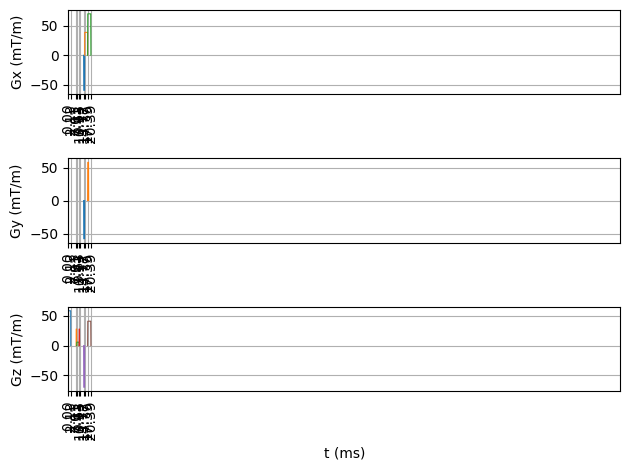

In [ ]:
seq.plot(label='lin', time_range=np.array([0, 1]) * TR, time_disp='ms',grad_disp='mT/m',show_blocks=True)


# Start to create sequence blocks

In [ ]:
seq = pp.Sequence(system)  # Create a new sequence object

# ======
# CONSTRUCT SEQUENCE
# ======


# Loop over phase encodes and define sequence blocks
for i in range(Ny):
    seq.add_block(rf, gz)
    seq.add_block(pp.make_delay(delay_TE1))
    seq.add_block(crush)
    seq.add_block(rf_180, gz_180)
    seq.add_block(crush)
    seq.add_block(pp.make_delay(delay_TE2))
    seq.add_block(gx_pre, pp.scale_grad(grad=gy_pre,scale=scale_area[1]), gz_reph)
    seq.add_block(gx, adc)
    seq.add_block(gx_spoil, pp.scale_grad(grad=gy_pre,scale=-scale_area[1]), gz_spoil)
    seq.add_block(pp.make_delay(delay_TR))



## Check sequence

In [13]:
ok, error_report = seq.check_timing()

if ok:
    print('Timing check passed successfully')
else:
    print('Timing check failed. Error listing follows:')
    [print(e) for e in error_report]


Timing check passed successfully


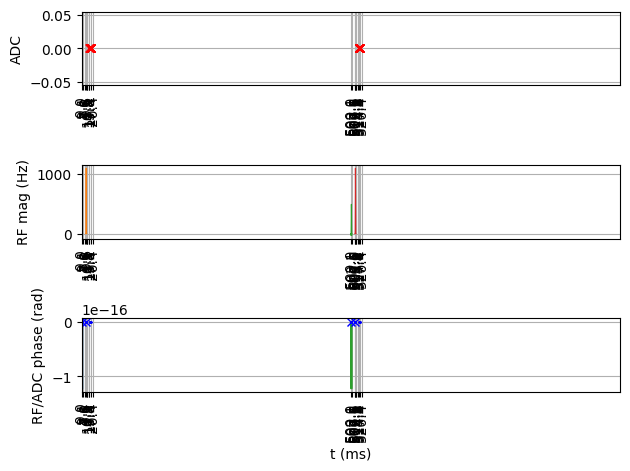

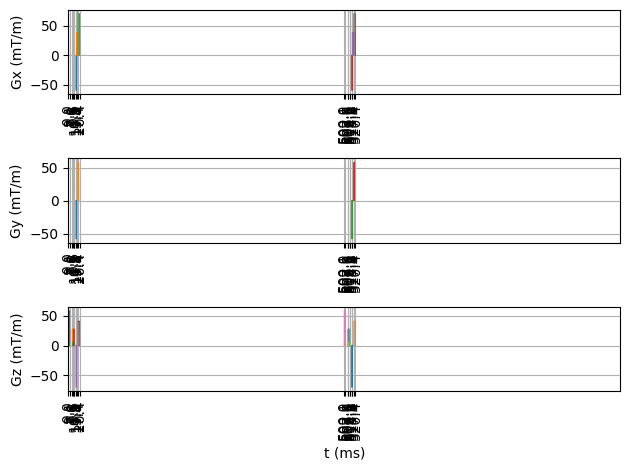

In [14]:
seq.plot(label='lin', time_range=np.array([0, 2]) * TR, time_disp='ms',grad_disp='mT/m',show_blocks=True)

# Write sequence to file

In [15]:
# Prepare the sequence output for the scanner
# store all hyperparameters
# Systems
seq.set_definition(key='system_max_grad', value=system.max_grad)
seq.set_definition(key='system_max_slew', value=system.max_slew)
seq.set_definition(key='system_rf_ringdown_time', value=system.rf_ringdown_time)
seq.set_definition(key='system_rf_dead_time', value=system.rf_dead_time)
seq.set_definition(key='AdcDeadTime', value=system.adc_dead_time)
seq.set_definition(key='GradientRasterTime', value=system.grad_raster_time)

# geometry
seq.set_definition(key='FOV', value=[fov, fov, slice_thickness * n_slices])
seq.set_definition(key='matrix', value=[Nx, Ny, 1])
seq.set_definition(key='nslices', value=n_slices)

# contrast
seq.set_definition(key='alpha', value=alpha)
seq.set_definition(key='TE', value=TE)
seq.set_definition(key='TR', value=TR)

# remaining seq parameters
seq.set_definition(key='rf_spoiling_inc', value=rf_spoiling_inc)
seq.set_definition(key='ro_duration', value=ro_duration)
seq.set_definition(key='spoiler_duration', value=spoiler_duration)

seq.set_definition(key='Name', value='bruker_SE')
seq.write("out/bruker_SE_dwell")

'8360d3de5c97030308b9b8db329a061c'